# DATA 56000: Neural Networks and Deep Learning
## Assignment #2 — Radial Basis Function Neural Network for Color Image Classification

**Lewis University — Spring 2026**

---

### Overview
This notebook implements a **Radial Basis Function Neural Network (RBFNN)** trained with the **hybrid learning method** to perform **pixel-level colour classification** on a standard colour test image.

| | |
|---|---|
| **Image** | Coffee-cup (scikit-image built-in, `data.coffee()`) — 128×128 crop |
| **Classes** | 3 — Light/Background · Midtones · Dark/Shadow |
| **Architecture** | Input(3) → RBF Hidden Layer(K centres) → Output(3 classes) |
| **Training** | Phase 1: K-Means (centres) · Phase 2: Least Squares (output weights) |

## 1 Imports & Setup

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import data
from skimage.transform import resize
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('All imports OK.')

All imports OK.


## 2 Image Loading & Label Creation

Each pixel is assigned one of **three classes** based on its ITU-R BT.601 perceived luminance:

$$Y = 0.299R + 0.587G + 0.114B$$

| Class | Name | Luminance range |
|---|---|---|
| 0 | Light / Background | Y ≥ 170 |
| 1 | Midtones | 85 ≤ Y < 170 |
| 2 | Dark / Shadow | Y < 85 |


In [25]:
IMAGE_SIZE = 128
CLASS_NAMES = ['Light/BG', 'Midtones', 'Dark/Shadow']
CLASS_COLORS = np.array([[255, 220, 150],    # warm yellow → Light
                          [100, 180, 100],   # green       → Midtones
                          [ 50,  80, 160]])  # blue        → Dark

def load_image(size=IMAGE_SIZE):
    """Load and resize the coffee image, return (img_uint8, label_map)."""
    raw = data.coffee()
    img = (resize(raw, (size, size), anti_aliasing=True) * 255).astype(np.uint8)
    lum = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
    labels = np.zeros(lum.shape, dtype=int)
    labels[lum >= 170]               = 0   # Light/BG
    labels[(lum >= 85) & (lum < 170)]= 1   # Midtones
    labels[lum < 85]                 = 2   # Dark/Shadow
    return img, labels

img, label_map = load_image()

X_all = (img.reshape(-1, 3) / 255.0).astype(np.float64)
y_all = label_map.flatten()

print(f'Image shape : {img.shape}')
print(f'Total pixels: {len(X_all):,}')
for i, name in enumerate(CLASS_NAMES):
    cnt = (y_all == i).sum()
    print(f'  Class {i} ({name:<12}): {cnt:,}  ({cnt/len(y_all)*100:.1f}%)')

Image shape : (128, 128, 3)
Total pixels: 16,384
  Class 0 (Light/BG    ): 1,783  (10.9%)
  Class 1 (Midtones    ): 8,530  (52.1%)
  Class 2 (Dark/Shadow ): 6,071  (37.1%)


### 2.1 Visualise the Original Image and Ground-Truth Labels

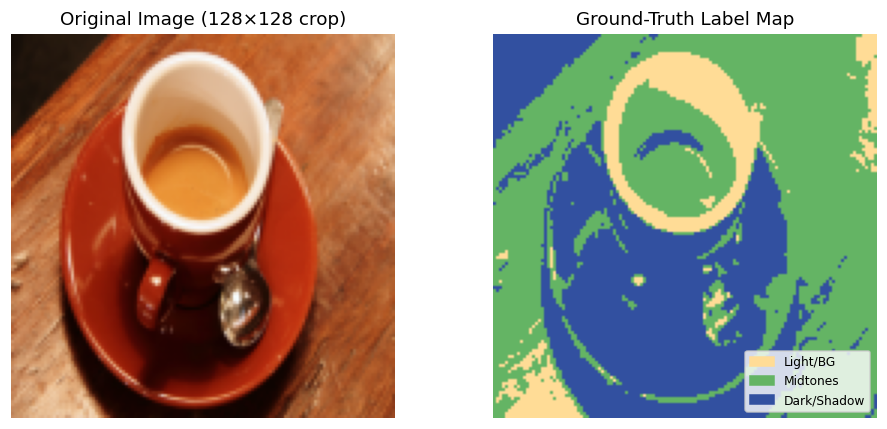

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(img)
axes[0].set_title('Original Image (128×128 crop)', fontsize=12)
axes[0].axis('off')

gt_rgb = CLASS_COLORS[label_map]
axes[1].imshow(gt_rgb)
axes[1].set_title('Ground-Truth Label Map', fontsize=12)
axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(3)]
axes[1].legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 3 Data Splitting

Stratified splits ensure each class is proportionally represented:
- **80%** training - **10%** validation - **10%** test

In [29]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,   test_size=0.10, random_state=42, stratify=y_tr)

print(f'Train : {len(X_tr):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_te):,}')

Train : 11,796
Val   : 1,311
Test  : 3,277


## 4 · Radial Basis Function Neural Network


In [31]:
class RBFNetworkHybrid:
    def __init__(self, num_centers=30, sigma_mult=1.0, reg=1e-4, seed=42):
        self.num_centers = num_centers
        self.sigma_mult  = sigma_mult
        self.reg         = reg
        self.seed        = seed

        self.centers = None   # shape (K, d)         — placed by K-Means
        self.sigmas  = None   # shape (K,)           — width of each RBF
        self.W_out   = None   # shape (K, n_classes) — output weights

    # ── Phase 1: K-Means centre placement ────────────────────────────────────
    def _fit_centers(self, X):
        km = KMeans(n_clusters=self.num_centers, n_init=10,
                    max_iter=300, random_state=self.seed)
        km.fit(X)
        self.centers = km.cluster_centers_

        # Width heuristic: nearest-neighbour distance between centres
        pairwise = np.sqrt(((self.centers[:, None, :] - self.centers[None, :, :]) ** 2).sum(axis=2))
        pairwise[pairwise == 0] = np.nan
        sigma = np.nanmean(np.nanmin(pairwise, axis=1)) * self.sigma_mult
        sigma = max(float(sigma), 1e-2)
        self.sigmas = np.ones(self.num_centers) * sigma

    # ── RBF activation: Gaussian kernel ──────────────────────────────────────
    def _rbf(self, X):
        diff    = X[:, np.newaxis, :] - self.centers[np.newaxis, :, :]
        sq_dist = np.sum(diff ** 2, axis=2)
        safe_s  = np.maximum(self.sigmas, 1e-6)
        return np.exp(-sq_dist / (2 * safe_s ** 2))

    # ── Phase 2: Least-squares output weights ─────────────────────────────────
    def _fit_weights(self, Phi, T):
        # Solve W = (Phi^T @ Phi + reg*I)^-1 @ Phi^T @ T
        A = Phi.T @ Phi + self.reg * np.eye(self.num_centers)
        B = Phi.T @ T
        self.W_out = np.linalg.solve(A, B)

    # ── Public API ────────────────────────────────────────────────────────────
    def fit(self, X, y):
        enc = OneHotEncoder(sparse_output=False)
        T   = enc.fit_transform(y.reshape(-1, 1))

        print('Phase 1: placing centres with K-Means...')
        self._fit_centers(X)
        print(f'         {self.num_centers} centres placed.')

        print('Phase 2: computing output weights with least squares...')
        Phi = self._rbf(X)
        self._fit_weights(Phi, T)
        print('Training complete.')
        return self

    def predict(self, X):
        Phi    = self._rbf(X)
        scores = Phi @ self.W_out
        return np.argmax(scores, axis=1)

print('RBFNetworkHybrid class defined.')

RBFNetworkHybrid class defined.


## 5 Hyperparameter Configuration

In [33]:
NUM_CENTERS = 30     # number of RBF centres (hidden neurons)
SIGMA_MULT = 1.0     # multiplier for the centre width heuristic
REG = 1e-4           # regularisation coefficient for least-squares
        
rbf = RBFNetworkHybrid(
    num_centers = NUM_CENTERS,
    sigma_mult = SIGMA_MULT,
    reg = REG,
    seed = 42,
)
print('Network configured.')

Network configured.


## 6 Train the Network

In [35]:
rbf.fit(X_tr, y_tr)

Phase 1: placing centres with K-Means...
         30 centres placed.
Phase 2: computing output weights with least squares...
Training complete.


## 6.1 RBF Centre Distribution

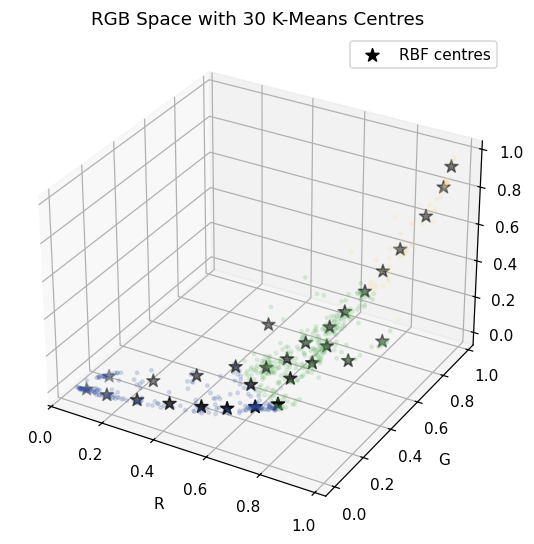

In [57]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Sample background points for context
step = 20
ax.scatter(X_tr[::step, 0], X_tr[::step, 1], X_tr[::step, 2],
           c=[CLASS_COLORS[c]/255 for c in y_tr[::step]],
           alpha=0.15, s=5)

# RBF centres
ax.scatter(rbf.centers[:, 0], rbf.centers[:, 1], rbf.centers[:, 2],
           c='black', s=80, marker='*', label='RBF centres')

ax.set_xlabel('R'); ax.set_ylabel('G'); ax.set_zlabel('B')
ax.set_title(f'RGB Space with {NUM_CENTERS} K-Means Centres')
ax.legend()
plt.tight_layout()
plt.show()

## 7 Evaluation on the Test Set

In [37]:
y_pred = rbf.predict(X_te)
acc = accuracy_score(y_te, y_pred)
cm = confusion_matrix(y_te, y_pred)

print(f'Test Accuracy : {acc*100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

Test Accuracy : 98.72%

Classification Report:
              precision    recall  f1-score   support

    Light/BG       0.98      0.96      0.97       357
    Midtones       0.99      0.99      0.99      1706
 Dark/Shadow       0.99      1.00      0.99      1214

    accuracy                           0.99      3277
   macro avg       0.99      0.98      0.98      3277
weighted avg       0.99      0.99      0.99      3277



### 7.1 Confusion Matrix

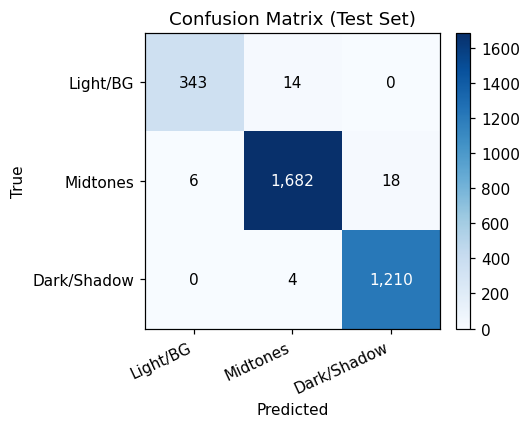

In [39]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (Test Set)')
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8 Full-Image Classification Map

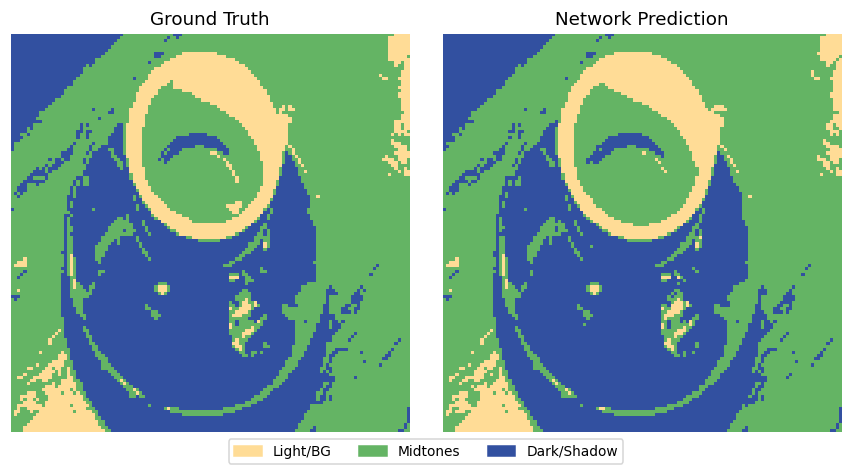

In [41]:
y_all_pred = rbf.predict(X_all)

gt_map = CLASS_COLORS[label_map]
pred_map = CLASS_COLORS[y_all_pred.reshape(IMAGE_SIZE, IMAGE_SIZE)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gt_map);   axes[0].set_title('Ground Truth', fontsize=12);       axes[0].axis('off')
axes[1].imshow(pred_map); axes[1].set_title('Network Prediction', fontsize=12); axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(3)]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.show()

## Generalization

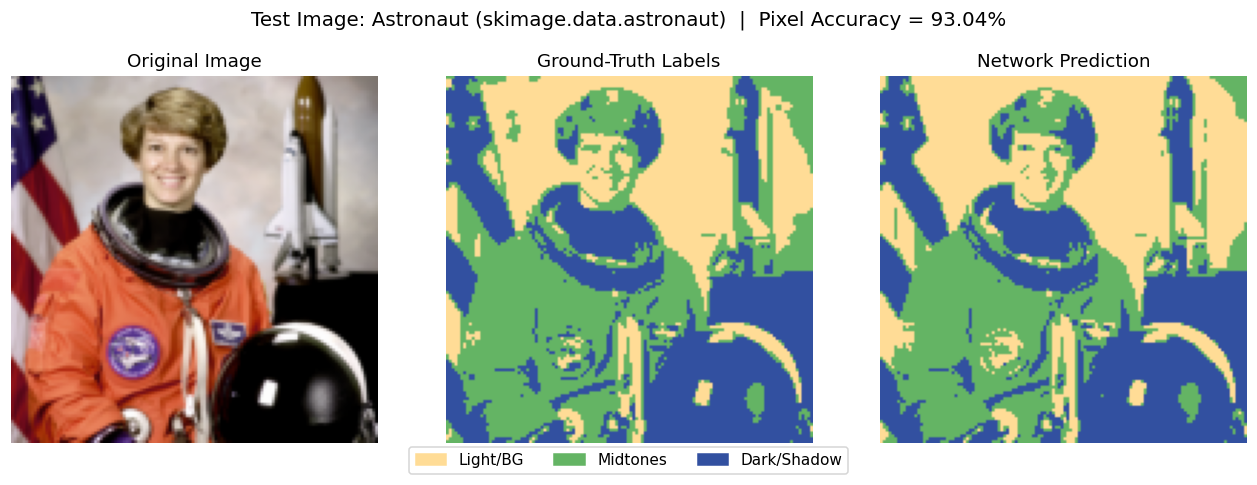

Astronaut (skimage.data.astronaut) — Pixel Accuracy: 93.04%
              precision    recall  f1-score   support

    Light/BG       0.83      1.00      0.91      4759
    Midtones       0.98      0.83      0.90      5984
 Dark/Shadow       0.99      0.98      0.98      5641

    accuracy                           0.93     16384
   macro avg       0.93      0.94      0.93     16384
weighted avg       0.94      0.93      0.93     16384



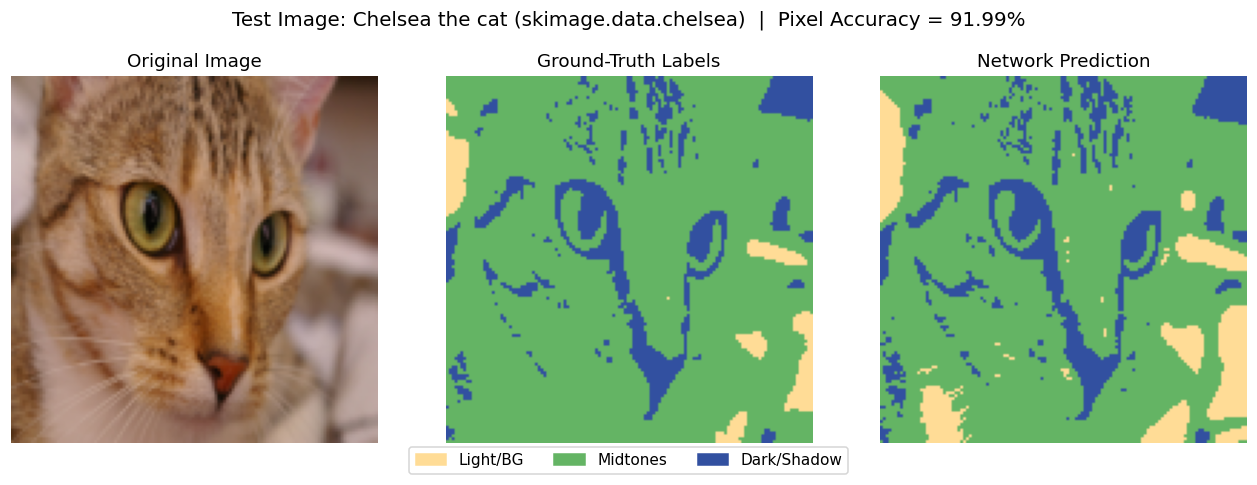

Chelsea the cat (skimage.data.chelsea) — Pixel Accuracy: 91.99%
              precision    recall  f1-score   support

    Light/BG       0.41      1.00      0.58       643
    Midtones       1.00      0.90      0.95     13708
 Dark/Shadow       0.84      1.00      0.91      2033

    accuracy                           0.92     16384
   macro avg       0.75      0.97      0.81     16384
weighted avg       0.96      0.92      0.93     16384



In [55]:
from skimage import data as skdata

def load_skimage(img_array, size=IMAGE_SIZE):
    """Accept any uint8 RGB or grey array; return (img_uint8, label_map, X, y)."""
    from skimage.transform import resize as sk_resize
    from skimage.color import gray2rgb

    if img_array.ndim == 2:
        img_array = gray2rgb(img_array)

    img = (sk_resize(img_array, (size, size), anti_aliasing=True) * 255).astype(np.uint8)
    lum = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
    labels = np.zeros(lum.shape, dtype=int)
    labels[lum >= 170]               = 0
    labels[(lum >= 85) & (lum < 170)]= 1
    labels[lum < 85]                 = 2
    X = (img.reshape(-1, 3) / 255.0).astype(np.float64)
    y = labels.flatten()
    return img, labels, X, y


def evaluate_and_plot(name, img, label_map, X, y_true):
    """Run the trained rbf on X, report accuracy, and plot results."""
    y_pred = rbf.predict(X)
    acc = accuracy_score(y_true, y_pred)

    pred_map = CLASS_COLORS[y_pred.reshape(IMAGE_SIZE, IMAGE_SIZE)]
    gt_map = CLASS_COLORS[label_map]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);       axes[0].set_title('Original Image');      axes[0].axis('off')
    axes[1].imshow(gt_map);    axes[1].set_title('Ground-Truth Labels'); axes[1].axis('off')
    axes[2].imshow(pred_map);  axes[2].set_title('Network Prediction');  axes[2].axis('off')

    patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(3)]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.05), fontsize=10)
    fig.suptitle(f'Test Image: {name}  |  Pixel Accuracy = {acc*100:.2f}%', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f'{name} — Pixel Accuracy: {acc*100:.2f}%')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


# ── Test image 1: Astronaut ───────────────────────────────────────────────────
img1, lm1, X1, y1 = load_skimage(skdata.astronaut())
evaluate_and_plot('Astronaut (skimage.data.astronaut)', img1, lm1, X1, y1)

# ── Test image 2: Chelsea the cat ─────────────────────────────────────────────
img3, lm3, X3, y3 = load_skimage(skdata.chelsea())
evaluate_and_plot('Chelsea the cat (skimage.data.chelsea)', img3, lm3, X3, y3)